# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Intifada Afkar Lazain Muhammad | 5054251029 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [57]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [58]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.info()
display(df.describe())
print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


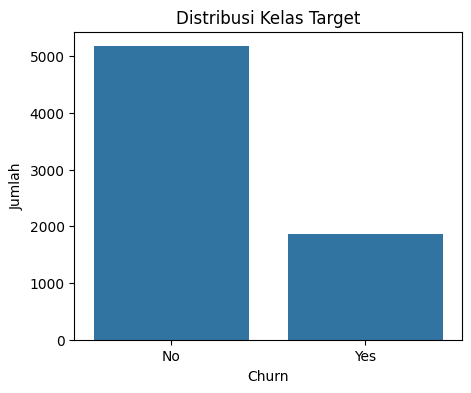

Churn
No     0.73463
Yes    0.26537
Name: count, dtype: float64


In [59]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_counts = df['Churn'].value_counts()
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xlabel('Churn')
plt.ylabel('Jumlah')
plt.title('Distribusi Kelas Target')
plt.show()
print(class_counts / len(df))

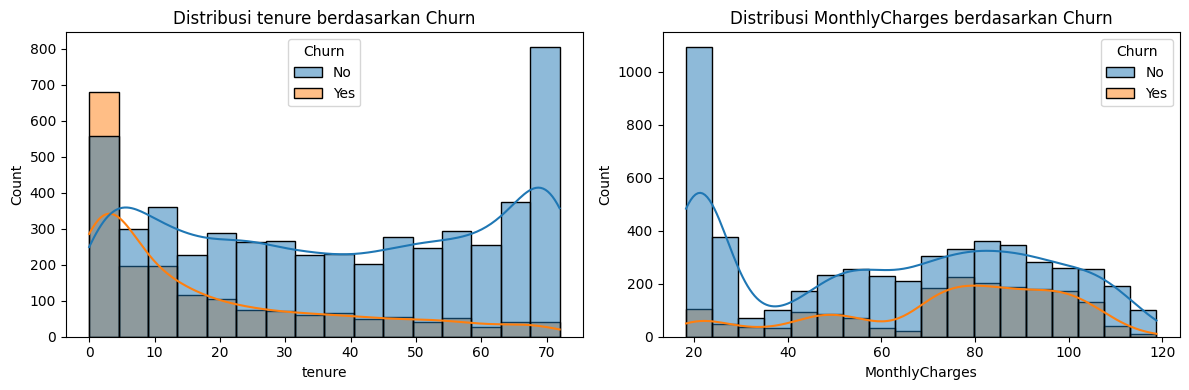

In [60]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax)
    ax.set_title(f'Distribusi {col} berdasarkan Churn')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [61]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

11


In [62]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [63]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [64]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [65]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
ann_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
ann_base.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(10,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [66]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_base = ann_base.predict(X_test_scaled)

## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [67]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']
act_models = {}
for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    act_models[act] = model

In [68]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan
act_results = pd.DataFrame({
    'Test Accuracy': {act: accuracy_score(y_test, m.predict(X_test_scaled)) for act, m in act_models.items()}
})
display(act_results)

,Test Accuracy
relu,0.785359
tanh,0.791045
logistic,0.795309


In [69]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']
act_models = {}
for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(50,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    act_models[act] = model

c:\Users\Lazzain\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [70]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan
act_results = pd.DataFrame({
    'Test Accuracy': {act: accuracy_score(y_test, m.predict(X_test_scaled)) for act, m in act_models.items()}
})
display(act_results)

,Test Accuracy
relu,0.776119
tanh,0.776830
logistic,0.799574


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [80]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
best_act = act_results['Test Accuracy'].idxmax()
architectures = [(2,), (5,), (10,), (50,), (100,), (150,)]
arch_models = {}
for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    arch_models[arch] = model

In [81]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = []
test_acc = []
for arch in architectures:
    train_acc.append(accuracy_score(y_train, arch_models[arch].predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, arch_models[arch].predict(X_test_scaled)))
arch_results = pd.DataFrame({'Arsitektur': [str(a) for a in architectures], 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})
display(arch_results)

,Arsitektur,Train Accuracy,Test Accuracy
0,"(2,)",0.804089,0.791756
1,"(5,)",0.805333,0.795309
2,"(10,)",0.805867,0.795309
3,"(50,)",0.807111,0.799574
4,"(100,)",0.806578,0.799574
5,"(150,)",0.806756,0.798152


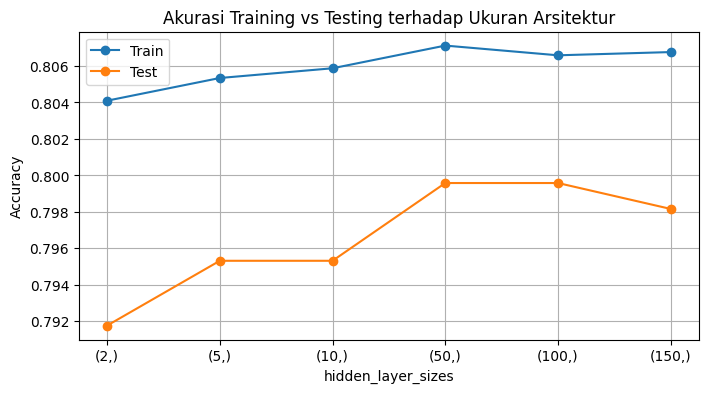

In [82]:

# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
labels = [str(a) for a in architectures]
plt.figure(figsize=(8, 4))
plt.plot(labels, train_acc, marker='o', label='Train')
plt.plot(labels, test_acc, marker='o', label='Test')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Accuracy')
plt.title('Akurasi Training vs Testing terhadap Ukuran Arsitektur')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [74]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
best_act_model = act_models[best_act]
best_arch = architectures[int(np.argmax(test_acc))]
best_arch_model = arch_models[best_arch]
final_models = {f'Aktivasi terbaik ({best_act})': best_act_model, f'Arsitektur terbaik {best_arch}': best_arch_model}
metrics = pd.DataFrame({
    name: {
        'Accuracy': accuracy_score(y_test, m.predict(X_test_scaled)),
        'Precision': precision_score(y_test, m.predict(X_test_scaled)),
        'Recall': recall_score(y_test, m.predict(X_test_scaled)),
        'F1-Score': f1_score(y_test, m.predict(X_test_scaled))
    } for name, m in final_models.items()
}).T
display(metrics)

,Accuracy,Precision,Recall,F1-Score
Aktivasi terbaik (logistic),0.799574,0.642857,0.553476,0.594828
"Arsitektur terbaik (50,)",0.799574,0.642857,0.553476,0.594828


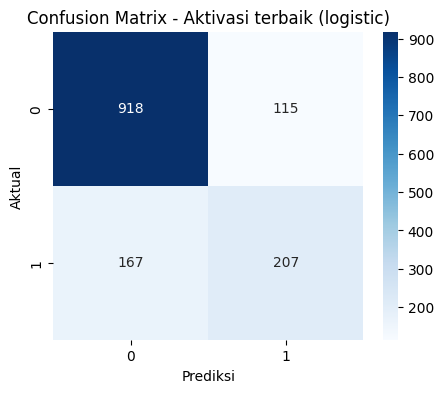

In [75]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_name = metrics['Accuracy'].idxmax()
best_model = final_models[best_name]
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

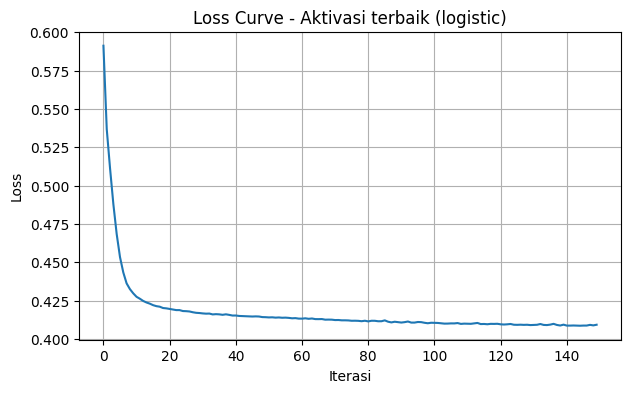

Iterasi berjalan: 150


In [76]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(7, 4))
plt.plot(best_model.loss_curve_)
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.title(f'Loss Curve - {best_name}')
plt.grid(True)
plt.show()
print('Iterasi berjalan:', best_model.n_iter_)

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

- Hasil nya mirip mirip dari ketiga fungsi aktivasi tersebut pada hidden layer 10, logistic paling bagus karena memang dibuat untuk mengelompokan output ke kelas antara 1 atau 0 sehingga memang tepat dengan fungsinya sehingga hasil maksimal. Namun peforma ketiga aktivasi tersebut mirip karena layer dari ANN tidak banyak sehingga tidak terlalu berasa. Tetapi jika hidden layer diperbanyak misal 50 maka perbedaan lebih terasa dimana logistic menang jauh sesuai hasil percobaan saya menang sekitar 2 persen. Sehingga mutlak bahwa logistik lebih cocok di kasus ini (saya tidak tahu bagaimana cara mengetahui aktivasi yang cocok secara langsung saya rasa tetap harus dilakukan percobaan).
- Menurut hasil experimen ukuran arsitektur paling maksimal adalah 50 sehingga diatas itu mulai terjadi gejala overfitting yang dimana ciri cirinya hasil akurasi di trainnya naik tetapi di test malah tetap atau turun.
- Sudah cukup konvergen karena kemiringannya sudah hampir tidak ada atau mendatar, jika masih menurun tajam saat max_iter tercapai saya akan menambah max_iter sampai sudah mendatar grafik loss functionnya

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan:
- Hasil akurasi ANN sangat bergantung pada hyperparameter yang diatur
- Butuh percobaan untuk mengetahui hyperparameter yang pas

Saran:
- Sesuai dengan deskripsi yang diberikan asdos bisa mencoba hyperparameter tuning seperti GridSearchCV supaya pasti dapat hyperparameter yang pas tidak coba coba manual, mencoba optimisizer lain seperti solver 'sgd', dan menambahkan regulasi alpha
- Bisa dicoba jika menambahkan fitur untuk mengetes jika akurasi bertambah
- Bisa mencoba model dengan hidden layer lebih dalam sebagai perbandingan fungsi aktivasi